In [3]:
import os
# os.environ["PATH"] = "/home/ubuntu/miniconda3/envs/automation/bin:" + os.environ["PATH"]

# Verify fix
# !which python
# !python --version


In [4]:
from transformers import AutoProcessor, CLIPSegForImageSegmentation
from PIL import Image
import torch

processor = AutoProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")

ModuleNotFoundError: No module named 'transformers'

In [14]:
image = Image.open("/home/ubuntu/additional_drive/shwan_data/scripts/all_frames/7_days_mini_croissants__816374020670__5/7_days_mini_croissants__816374020670__5_frame_001.png").convert("RGB")
texts = ["7_days_mini_croissants","all black objects"]
inputs = processor(text=texts, images=[image]*len(texts), padding=True, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
masks = (outputs.logits.sigmoid() > 0.5).float()  # binary masks

In [16]:
# masks

In [4]:
import torch
from transformers import AutoProcessor, CLIPSegForImageSegmentation
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Load model and processor
processor = AutoProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")


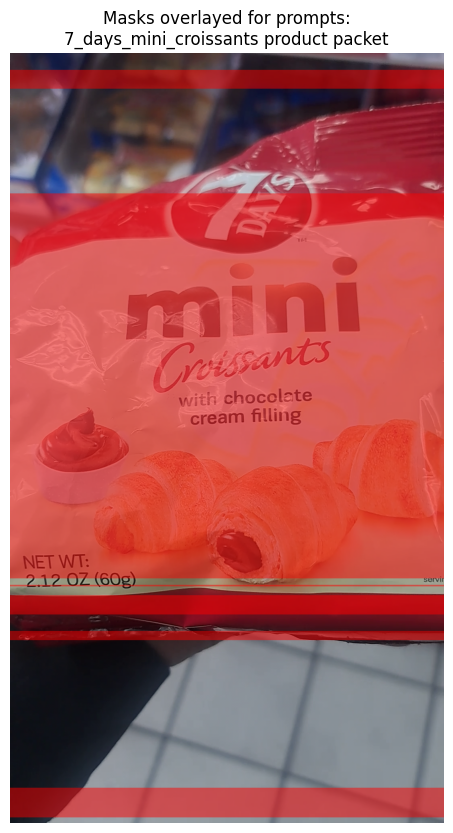

In [30]:
# Load your image
image_path = "/home/ubuntu/additional_drive/shwan_data/scripts/all_frames/7_days_mini_croissants__816374020670__5/7_days_mini_croissants__816374020670__5_frame_001.png"
image = Image.open(image_path).convert("RGB")
image_np = np.array(image)

# Prompts
# texts = ["7_days_mini_croissants_lays"]
texts = ["7_days_mini_croissants product packet"]
# Prepare inputs
inputs = processor(
    text=texts,
    images=[image] * len(texts),
    padding=True,
    truncation=True,
    return_tensors="pt"
)

# Run model
with torch.no_grad():
    outputs = model(**inputs)

# Get masks (float values between 0–1)
masks = outputs.logits.sigmoid().cpu().numpy()

# Prepare overlay
overlay = image_np.copy().astype(np.float32)
alpha = 0.5  # transparency
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]

for i, mask in enumerate(masks):
    mask_resized = cv2.resize(mask[0], (image_np.shape[1], image_np.shape[0]))
    mask_norm = (mask_resized - mask_resized.min()) / (mask_resized.max() - mask_resized.min() + 1e-8)

    color = np.array(colors[i % len(colors)], dtype=np.float32)
    for c in range(3):
        overlay[..., c] = np.where(
            mask_norm > 0.3,
            overlay[..., c] * (1 - alpha) + color[c] * alpha,
            overlay[..., c],
        )

# Convert back to uint8 image
overlay = np.clip(overlay, 0, 255).astype(np.uint8)

# Show results
plt.figure(figsize=(10, 10))
plt.imshow(overlay)
plt.axis("off")
plt.title("Masks overlayed for prompts:\n" + ", ".join(texts))
plt.show()


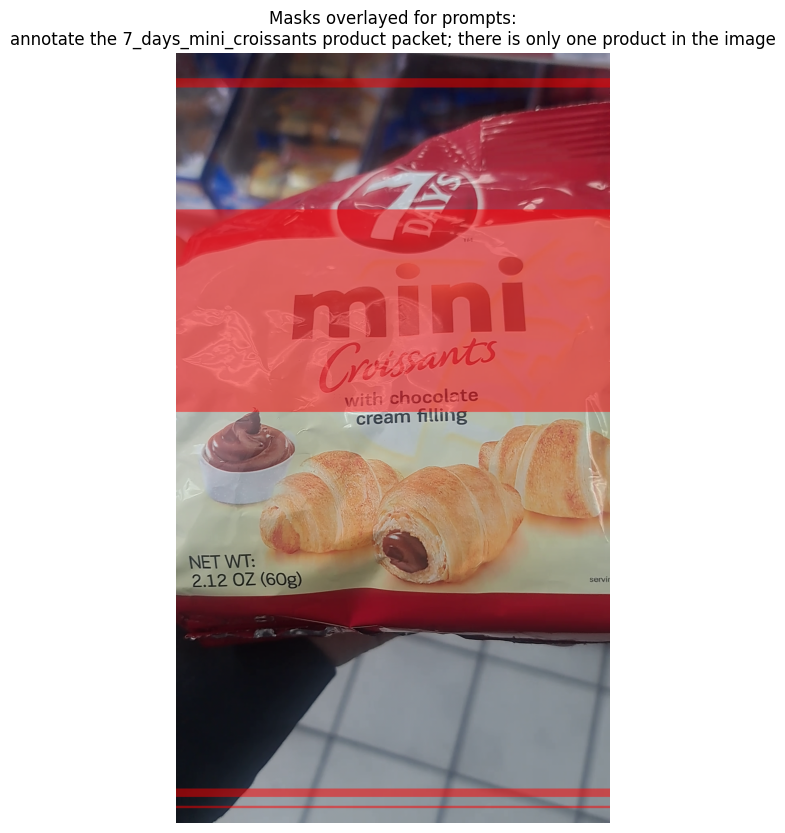

In [31]:
# Load your image
image_path = "/home/ubuntu/additional_drive/shwan_data/scripts/all_frames/7_days_mini_croissants__816374020670__5/7_days_mini_croissants__816374020670__5_frame_001.png"
image = Image.open(image_path).convert("RGB")
image_np = np.array(image)

# Prompts
# texts = ["7_days_mini_croissants_lays"]
texts = ["annotate the 7_days_mini_croissants product packet; there is only one product in the image"]
# Prepare inputs
inputs = processor(
    text=texts,
    images=[image] * len(texts),
    padding=True,
    truncation=True,
    return_tensors="pt"
)

# Run model
with torch.no_grad():
    outputs = model(**inputs)

# Get masks (float values between 0–1)
masks = outputs.logits.sigmoid().cpu().numpy()

# Prepare overlay
overlay = image_np.copy().astype(np.float32)
alpha = 0.5  # transparency
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]

for i, mask in enumerate(masks):
    mask_resized = cv2.resize(mask[0], (image_np.shape[1], image_np.shape[0]))
    mask_norm = (mask_resized - mask_resized.min()) / (mask_resized.max() - mask_resized.min() + 1e-8)

    color = np.array(colors[i % len(colors)], dtype=np.float32)
    for c in range(3):
        overlay[..., c] = np.where(
            mask_norm > 0.3,
            overlay[..., c] * (1 - alpha) + color[c] * alpha,
            overlay[..., c],
        )

# Convert back to uint8 image
overlay = np.clip(overlay, 0, 255).astype(np.uint8)

# Show results
plt.figure(figsize=(10, 10))
plt.imshow(overlay)
plt.axis("off")
plt.title("Masks overlayed for prompts:\n" + ", ".join(texts))
plt.show()


/home/ubuntu/miniconda3/envs/automation/lib/python3.9/site-packages/transformers/image_processing_utils.py:51: UserWarning: The following named arguments are not valid for `ViTImageProcessor.preprocess` and were ignored: 'padding', 'truncation'
  return self.preprocess(images, **kwargs)


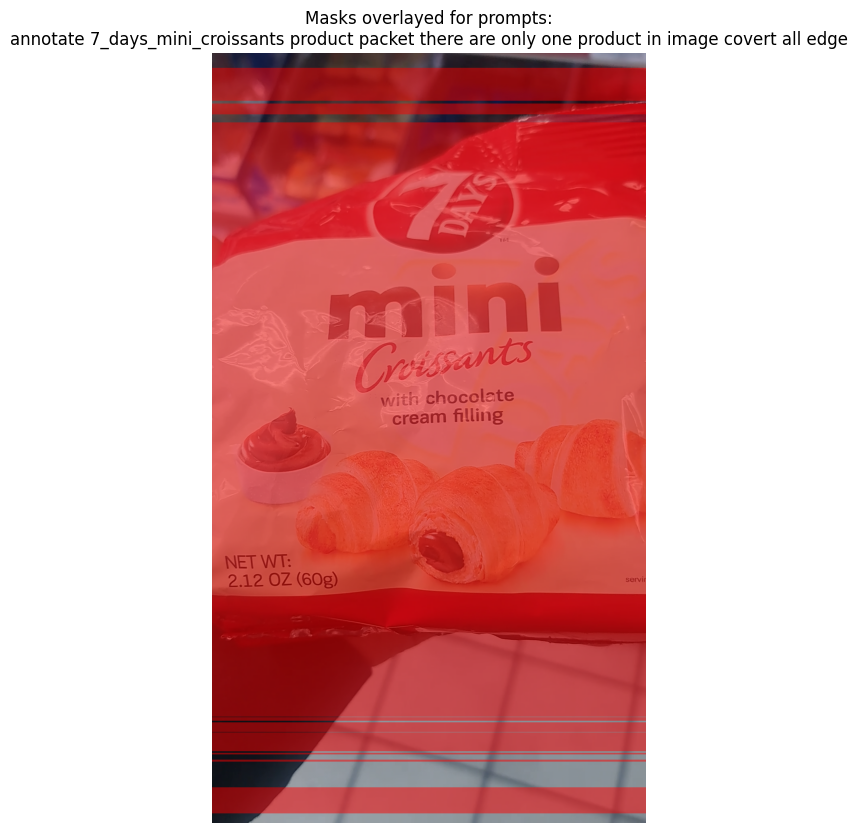

In [5]:
# Load your image
image_path = "/home/ubuntu/additional_drive/shwan_data/scripts/all_frames/7_days_mini_croissants__816374020670__5/7_days_mini_croissants__816374020670__5_frame_001.png"
image = Image.open(image_path).convert("RGB")
image_np = np.array(image)

# Prompts
# texts = ["7_days_mini_croissants_lays"]
texts = ["annotate 7_days_mini_croissants product packet there are only one product"]
# Prepare inputs
inputs = processor(
    text=texts,
    images=[image] * len(texts),
    padding=True,
    truncation=True,
    return_tensors="pt"
)

# Run model
with torch.no_grad():
    outputs = model(**inputs)

# Get masks (float values between 0–1)
masks = outputs.logits.sigmoid().cpu().numpy()

# Prepare overlay
overlay = image_np.copy().astype(np.float32)
alpha = 0.5  # transparency
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]

for i, mask in enumerate(masks):
    mask_resized = cv2.resize(mask[0], (image_np.shape[1], image_np.shape[0]))
    mask_norm = (mask_resized - mask_resized.min()) / (mask_resized.max() - mask_resized.min() + 1e-8)

    color = np.array(colors[i % len(colors)], dtype=np.float32)
    for c in range(3):
        overlay[..., c] = np.where(
            mask_norm > 0.3,
            overlay[..., c] * (1 - alpha) + color[c] * alpha,
            overlay[..., c],
        )

# Convert back to uint8 image
overlay = np.clip(overlay, 0, 255).astype(np.uint8)

# Show results
plt.figure(figsize=(10, 10))
plt.imshow(overlay)
plt.axis("off")
plt.title("Masks overlayed for prompts:\n" + ", ".join(texts))
plt.show()
